In [1]:
# 7.2 다수결 투표를 사용한 분류 앙상블

In [33]:
#7.2.2 다수결 투표 방식을 사용하여 예측 만들기
import numpy as np
from sklearn.linear_model import LogisticRegression, Perceptron, SGDClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, train_test_split, cross_val_score
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Iris 데이터 로드 및 분할
iris = load_iris()
X, y = iris.data, iris.target
X_overall_train, X_overall_test, y_overall_train, y_overall_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. K-겹 교차 검증 설정 (훈련 세트에 적용)
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# 3. 기본 분류기 파이프라인 생성 (StandardScaler 포함)
pipe_clf1 = Pipeline([('scaler', StandardScaler()), ('perceptron', Perceptron(random_state=1))])
pipe_clf2 = Pipeline([('scaler', StandardScaler()), ('adaline_sgd', SGDClassifier(loss='log_loss', random_state=1))])
pipe_clf3 = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(random_state=1, solver='liblinear'))])
pipe_clf4 = Pipeline([('scaler', StandardScaler()), ('svc', SVC(random_state=1, probability=True))])
pipe_clf5 = Pipeline([('scaler', StandardScaler()), ('dt', DecisionTreeClassifier(random_state=1))])
pipe_clf6 = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5))])

# 4. VotingClassifier 앙상블 모델 생성
eclf_hard = VotingClassifier(estimators=[
    ('perceptron_pipe', pipe_clf1),
    ('adaline_sgd_pipe', pipe_clf2),
    ('lr_pipe', pipe_clf3),
    ('svc_pipe', pipe_clf4),
    ('dt_pipe', pipe_clf5),
    ('knn_pipe', pipe_clf6)
], voting='hard')

eclf_soft = VotingClassifier(estimators=[
    ('adaline_sgd_pipe', pipe_clf2),
    ('lr_pipe', pipe_clf3),
    ('svc_pipe', pipe_clf4),
    ('dt_pipe', pipe_clf5),
    ('knn_pipe', pipe_clf6)
], voting='soft')

eclf_soft_weighted = VotingClassifier(estimators=[
    ('adaline_sgd_pipe', pipe_clf2),
    ('lr_pipe', pipe_clf3),
    ('svc_pipe', pipe_clf4),
    ('dt_pipe', pipe_clf5),
    ('knn_pipe', pipe_clf6)
], voting='soft', weights=[1, 1, 2, 1, 2])

# 5. cross_val_score를 이용한 K-Fold 교차 검증 및 결과 출력
print("\n--- cross_val_score를 이용한 K-Fold 교차 검증 결과 (평균 정확도) ---")

print("\n### 앙상블 모델 ###")
# 하드 보팅
scores = cross_val_score(estimator=eclf_hard, X=X_overall_train, y=y_overall_train, cv=kf, scoring='accuracy')
print(f"Average Hard Voting Accuracy: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

# 소프트 보팅
scores = cross_val_score(estimator=eclf_soft, X=X_overall_train, y=y_overall_train, cv=kf, scoring='accuracy')
print(f"Average Soft Voting Accuracy: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

# 가중치 소프트 보팅
scores = cross_val_score(estimator=eclf_soft_weighted, X=X_overall_train, y=y_overall_train, cv=kf, scoring='accuracy')
print(f"Average Weighted Soft Voting Accuracy: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

print("\n### 개별 기본 분류기 ###")
# 퍼셉트론
scores = cross_val_score(estimator=pipe_clf1, X=X_overall_train, y=y_overall_train, cv=kf, scoring='accuracy')
print(f"Average Perceptron Accuracy: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

# 아달라인(SGD)
scores = cross_val_score(estimator=pipe_clf2, X=X_overall_train, y=y_overall_train, cv=kf, scoring='accuracy')
print(f"Average Adaline(SGD) Accuracy: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

# 로지스틱 회귀
scores = cross_val_score(estimator=pipe_clf3, X=X_overall_train, y=y_overall_train, cv=kf, scoring='accuracy')
print(f"Average Logistic Regression Accuracy: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

# SVC
scores = cross_val_score(estimator=pipe_clf4, X=X_overall_train, y=y_overall_train, cv=kf, scoring='accuracy')
print(f"Average SVC Accuracy: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

# 결정 트리
scores = cross_val_score(estimator=pipe_clf5, X=X_overall_train, y=y_overall_train, cv=kf, scoring='accuracy')
print(f"Average Decision Tree Accuracy: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

# KNN
scores = cross_val_score(estimator=pipe_clf6, X=X_overall_train, y=y_overall_train, cv=kf, scoring='accuracy')
print(f"Average KNN Accuracy: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

# 최종 결과는 모델의 일반화 성능(평균 정확도) 및 일관성(표준 편차)을 예측하는 데 사용됩니다.



--- cross_val_score를 이용한 K-Fold 교차 검증 결과 (평균 정확도) ---

### 앙상블 모델 ###
Average Hard Voting Accuracy: 0.9417 (+/- 0.0651)
Average Soft Voting Accuracy: 0.9167 (+/- 0.0745)
Average Weighted Soft Voting Accuracy: 0.9333 (+/- 0.0726)

### 개별 기본 분류기 ###
Average Perceptron Accuracy: 0.8500 (+/- 0.1434)
Average Adaline(SGD) Accuracy: 0.8917 (+/- 0.1121)
Average Logistic Regression Accuracy: 0.8750 (+/- 0.1003)
Average SVC Accuracy: 0.9500 (+/- 0.0764)
Average Decision Tree Accuracy: 0.9167 (+/- 0.0745)
Average KNN Accuracy: 0.9417 (+/- 0.0750)


--- 홀드아웃 테스트 세트에 대한 최종 모델 성능 (Accuracy) ---
Fitting Perceptron (Pipe)...
Accuracy for Perceptron (Pipe): 0.8667
Fitting Adaline(SGD) (Pipe)...
Accuracy for Adaline(SGD) (Pipe): 1.0000
Fitting Logistic Regression (Pipe)...
Accuracy for Logistic Regression (Pipe): 0.9667
Fitting SVC (Pipe)...
Accuracy for SVC (Pipe): 1.0000
Fitting Decision Tree (Pipe)...
Accuracy for Decision Tree (Pipe): 1.0000
Fitting KNN (Pipe)...
Accuracy for KNN (Pipe): 1.0000
Fitting Hard Voting Ensemble...
Accuracy for Hard Voting Ensemble: 1.0000
Fitting Soft Voting Ensemble...
Accuracy for Soft Voting Ensemble: 1.0000
Fitting Weighted Soft Voting Ensemble...
Accuracy for Weighted Soft Voting Ensemble: 1.0000

--- ROC Curve 및 AUC 스코어 (predict_proba 지원 모델) ---


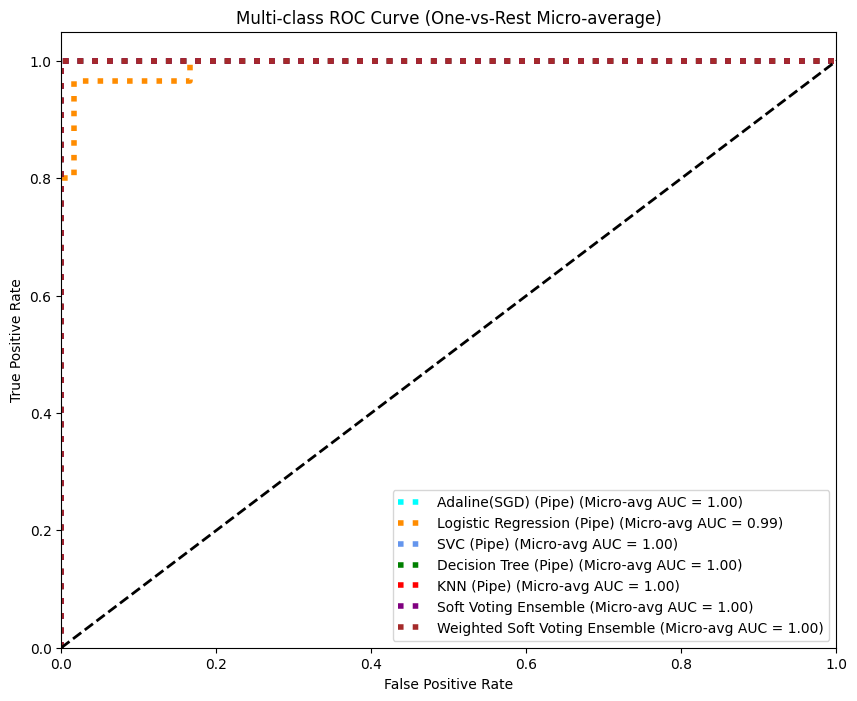

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# 1. 최종 모델 훈련 및 홀드아웃 테스트 세트 평가
# 이전에 정의된 파이프라인과 앙상블 모델 객체들을 사용합니다.

# 훈련이 필요한 모델 목록
models_to_fit = {
    "Perceptron (Pipe)": pipe_clf1,
    "Adaline(SGD) (Pipe)": pipe_clf2,
    "Logistic Regression (Pipe)": pipe_clf3,
    "SVC (Pipe)": pipe_clf4,
    "Decision Tree (Pipe)": pipe_clf5,
    "KNN (Pipe)": pipe_clf6,
    "Hard Voting Ensemble": eclf_hard,
    "Soft Voting Ensemble": eclf_soft,
    "Weighted Soft Voting Ensemble": eclf_soft_weighted,
}

print("--- 홀드아웃 테스트 세트에 대한 최종 모델 성능 (Accuracy) ---")
fitted_models = {}
for name, model in models_to_fit.items():
    print(f"Fitting {name}...")
    model.fit(X_overall_train, y_overall_train)
    fitted_models[name] = model
    y_pred = model.predict(X_overall_test)
    accuracy = accuracy_score(y_overall_test, y_pred)
    print(f"Accuracy for {name}: {accuracy:.4f}")

# 2. ROC 곡선 및 AUC 스코어 계산 (predict_proba를 지원하는 분류기만)

print("\n--- ROC Curve 및 AUC 스코어 (predict_proba 지원 모델) ---")

# 다중 클래스 ROC를 위해 y_test를 이진화
n_classes = len(np.unique(y_overall_test))
y_test_binarized = label_binarize(y_overall_test, classes=np.unique(y_overall_test))

# predict_proba를 지원하는 모델 필터링
roc_models = {
    name: model for name, model in fitted_models.items() if hasattr(model, "predict_proba")
}

plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown'])
lw = 2

for i, (name, model) in enumerate(roc_models.items()):
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_overall_test)

        # 각 클래스에 대한 ROC 및 AUC 계산 (One-vs-Rest)
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        for j in range(n_classes):
            fpr[j], tpr[j], _ = roc_curve(y_test_binarized[:, j], y_score[:, j])
            roc_auc[j] = auc(fpr[j], tpr[j])

        # Micro-average ROC curve and AUC
        fpr_micro, tpr_micro, _ = roc_curve(y_test_binarized.ravel(), y_score.ravel())
        roc_auc_micro = auc(fpr_micro, tpr_micro)

        # Plot micro-average ROC curve
        plt.plot(fpr_micro, tpr_micro, color=next(colors), linestyle=':', linewidth=4,
                 label=f'{name} (Micro-avg AUC = {roc_auc_micro:.2f})')
    else:
        print(f"Warning: {name} does not support predict_proba, skipping ROC/AUC.")

plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest Micro-average)')
plt.legend(loc="lower right")
plt.show()

In [92]:
# 7.2.3 앙상블 분류기의 평가와 튜닝
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("palashfendarkar/wa-fnusec-telcocustomerchurn")

# Construct the full path to the CSV file
dataset_dir = path  # 'path' variable is from the previous cell's output
csv_file_name = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
full_csv_path = os.path.join(dataset_dir, csv_file_name)

# Load the CSV file into a pandas DataFrame
df_churn = pd.read_csv(full_csv_path)
df_churn.info()


Using Colab cache for faster access to the 'wa-fnusec-telcocustomerchurn' dataset.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contra

In [93]:
# 'TotalCharges' 컬럼 처리
# 공백을 NaN으로 변환하고 숫자형으로 변환
df_churn['TotalCharges'] = pd.to_numeric(df_churn['TotalCharges'], errors='coerce')

# NaN 값 확인 및 처리 (여기서는 중간값으로 채움)
print("TotalCharges 컬럼의 NaN 값:", df_churn['TotalCharges'].isnull().sum())
df_churn['TotalCharges'] = df_churn['TotalCharges'].fillna(df_churn['TotalCharges'].median())
print("TotalCharges 컬럼의 NaN 처리 후 값:", df_churn['TotalCharges'].isnull().sum())

# 'customerID' 컬럼은 모델링에 필요 없으므로 제거
if 'customerID' in df_churn.columns:
    df_churn.drop('customerID', axis=1, inplace=True)

# 'Churn' 컬럼을 이진 값으로 변환 (Yes: 1, No: 0)
df_churn['Churn'] = df_churn['Churn'].map({'Yes': 1, 'No': 0})

# One-Hot Encoding
# 'Churn' 컬럼은 이미 숫자로 변환되었으므로 'object' 타입에서 제외됩니다.
df_churn_encoded = pd.get_dummies(df_churn, columns=df_churn.select_dtypes(include='object').columns, drop_first=True)

print("\n처리 후 데이터셋 정보:")
df_churn_encoded.info()




TotalCharges 컬럼의 NaN 값: 11
TotalCharges 컬럼의 NaN 처리 후 값: 0

처리 후 데이터셋 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   Churn                                  7043 non-null   int64  
 5   gender_Male                            7043 non-null   bool   
 6   Partner_Yes                            7043 non-null   bool   
 7   Dependents_Yes                         7043 non-null   bool   
 8   PhoneService_Yes                       7043 non-null   bool   
 9   MultipleLines_No phone service         7043 non-null   bool   
 10 

In [95]:
from sklearn.model_selection import train_test_split

# 특성(X)과 타겟 변수(y) 분리
X = df_churn_encoded.drop('Churn', axis=1)
y = df_churn_encoded['Churn']

# 훈련 세트와 테스트 세트 분리 (80% 훈련, 20% 테스트)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("데이터 분리 완료:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# 클래스 불균형 확인 (선택 사항)
print("\ny_train의 클래스 분포:\n", y_train.value_counts(normalize=True))
print("y_test의 클래스 분포:\n", y_test.value_counts(normalize=True))

데이터 분리 완료:
X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)

y_train의 클래스 분포:
 Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
y_test의 클래스 분포:
 Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [97]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score

# X_train, X_test, y_train, y_test는 이전 셀에서 df_churn_encoded로부터 이미 정의되었습니다.

# 1. 개별 분류기 파이프라인 정의 (StandardScaler 포함)
pipe_lr = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(random_state=42, solver='liblinear'))])
pipe_dt = Pipeline([('scaler', StandardScaler()), ('dt', DecisionTreeClassifier(random_state=42))])
pipe_knn = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

# 2. 하이퍼파라미터 그리드 정의
param_grid_lr = {
    'lr__C': [0.01, 0.1, 1, 10, 100]
}

param_grid_dt = {
    'dt__max_depth': [3, 5, 7, 10, None],
    'dt__min_samples_leaf': [1, 5, 10]
}

param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance']
}

# 3. K-Fold 교차 검증 설정 (불균형 데이터를 위한 StratifiedKFold 사용)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- 개별 모델 튜닝 ---")

best_clfs = {}

# 로지스틱 회귀 튜닝
grid_lr = GridSearchCV(pipe_lr, param_grid=param_grid_lr, cv=kf, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_train, y_train)
print(f"Logistic Regression - 최적 파라미터: {grid_lr.best_params_}")
print(f"Logistic Regression - 최적 ROC AUC: {grid_lr.best_score_:.4f}")
best_clfs['lr'] = grid_lr.best_estimator_

# 결정 트리 튜닝
grid_dt = GridSearchCV(pipe_dt, param_grid=param_grid_dt, cv=kf, scoring='roc_auc', n_jobs=-1)
grid_dt.fit(X_train, y_train)
print(f"Decision Tree - 최적 파라미터: {grid_dt.best_params_}")
print(f"Decision Tree - 최적 ROC AUC: {grid_dt.best_score_:.4f}")
best_clfs['dt'] = grid_dt.best_estimator_

# KNN 튜닝
grid_knn = GridSearchCV(pipe_knn, param_grid=param_grid_knn, cv=kf, scoring='roc_auc', n_jobs=-1)
grid_knn.fit(X_train, y_train)
print(f"KNN - 최적 파라미터: {grid_knn.best_params_}")
print(f"KNN - 최적 ROC AUC: {grid_knn.best_score_:.4f}")
best_clfs['knn'] = grid_knn.best_estimator_

print("\n--- 앙상블 모델 (VotingClassifier) 튜닝 ---")

# 4. 최적화된 개별 분류기를 사용한 VotingClassifier 정의
# LogisticRegression, DecisionTreeClassifier, KNeighborsClassifier 모두 predict_proba 지원
eclf_tuned_soft = VotingClassifier(estimators=[
    ('lr', best_clfs['lr']),
    ('dt', best_clfs['dt']),
    ('knn', best_clfs['knn'])
], voting='soft', n_jobs=-1)

# 5. VotingClassifier의 가중치 튜닝을 위한 하이퍼파라미터 그리드 정의
param_grid_eclf_soft = {
    'weights': [[1,1,1], [1,1,2], [1,2,1], [2,1,1], [1,2,2], [2,1,2], [2,2,1], [1,1,3], [1,3,1], [3,1,1]]
}

# 6. VotingClassifier 튜닝
grid_eclf_soft = GridSearchCV(eclf_tuned_soft, param_grid=param_grid_eclf_soft, cv=kf, scoring='roc_auc', n_jobs=-1)
grid_eclf_soft.fit(X_train, y_train)

print(f"Voting Classifier (Soft) - 최적 파라미터: {grid_eclf_soft.best_params_}")
print(f"Voting Classifier (Soft) - 최적 ROC AUC: {grid_eclf_soft.best_score_:.4f}")
best_ensemble_clf = grid_eclf_soft.best_estimator_

print("\n--- 최종 모델 테스트 세트 평가 ---")

# 개별 최적 모델 테스트 세트 평가
for name, clf in best_clfs.items():
    y_pred_proba = clf.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Optimized {name} - Test ROC AUC: {roc_auc:.4f}, Test Accuracy: {accuracy:.4f}")

# 앙상블 최적 모델 테스트 세트 평가
y_pred_proba_ensemble = best_ensemble_clf.predict_proba(X_test)[:, 1]
roc_auc_ensemble = roc_auc_score(y_test, y_pred_proba_ensemble)
y_pred_ensemble = best_ensemble_clf.predict(X_test)
accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
print(f"Optimized Voting Classifier (Soft) - Test ROC AUC: {roc_auc_ensemble:.4f}, Test Accuracy: {accuracy_ensemble:.4f}")

--- 개별 모델 튜닝 ---
Logistic Regression - 최적 파라미터: {'lr__C': 10}
Logistic Regression - 최적 ROC AUC: 0.8463
Decision Tree - 최적 파라미터: {'dt__max_depth': 5, 'dt__min_samples_leaf': 1}
Decision Tree - 최적 ROC AUC: 0.8294
KNN - 최적 파라미터: {'knn__n_neighbors': 9, 'knn__weights': 'uniform'}
KNN - 최적 ROC AUC: 0.8028

--- 앙상블 모델 (VotingClassifier) 튜닝 ---
Voting Classifier (Soft) - 최적 파라미터: {'weights': [3, 1, 1]}
Voting Classifier (Soft) - 최적 ROC AUC: 0.8468

--- 최종 모델 테스트 세트 평가 ---
Optimized lr - Test ROC AUC: 0.8410, Test Accuracy: 0.8034
Optimized dt - Test ROC AUC: 0.8284, Test Accuracy: 0.7942
Optimized knn - Test ROC AUC: 0.7992, Test Accuracy: 0.7700
Optimized Voting Classifier (Soft) - Test ROC AUC: 0.8423, Test Accuracy: 0.8055


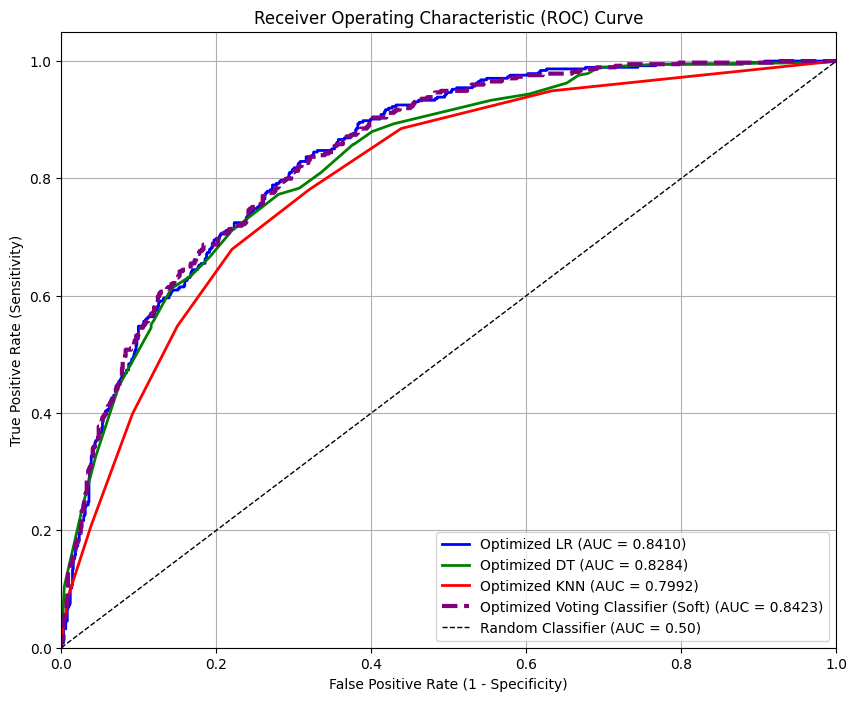

In [101]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'purple'] # Color for LR, DT, KNN, Ensemble

# Plot ROC curves for individual optimized classifiers
for i, (name, clf) in enumerate(best_clfs.items()):
    # predict_proba returns probabilities for each class [P(class 0), P(class 1)]
    y_pred_proba = clf.predict_proba(X_test)[:, 1]  # Probability of the positive class (Churn=1)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'Optimized {name.upper()} (AUC = {roc_auc:.4f})')

# Plot ROC curve for the optimized Voting Classifier
y_pred_proba_ensemble = best_ensemble_clf.predict_proba(X_test)[:, 1]
fpr_ensemble, tpr_ensemble, _ = roc_curve(y_test, y_pred_proba_ensemble)
roc_auc_ensemble = auc(fpr_ensemble, tpr_ensemble)
plt.plot(fpr_ensemble, tpr_ensemble, color=colors[3], lw=3, linestyle='--', label=f'Optimized Voting Classifier (Soft) (AUC = {roc_auc_ensemble:.4f})')

# Plot the random classifier line
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [106]:
# 7.3 배깅: 부트스트랩 샘플링을 통한 분류 앙상블
import pandas as pd
df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/'
                      'machine-learning-databases/wine/wine.data',
                      header=None)

df_wine.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue', 'OD280/OD315 of diluted wines',
                   'Proline']

# 클래스 1 제외
df_wine = df_wine[df_wine['Class label'] != 1]

# 특성 2개 선택
y = df_wine['Class label'].values
X = df_wine[['Alcohol', 'OD280/OD315 of diluted wines']].values

In [107]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test =\
            train_test_split(X, y,
                             test_size=0.2,
                             random_state=1,
                             stratify=y)

In [108]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(criterion='entropy',
                              max_depth=None,
                              random_state=1)

bag = BaggingClassifier(estimator=tree,
                        n_estimators=500,
                        max_samples=1.0,
                        max_features=1.0,
                        bootstrap=True,
                        bootstrap_features=False,
                        n_jobs=1,
                        random_state=1)

In [109]:
from sklearn.metrics import accuracy_score


tree = tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

tree_train = accuracy_score(y_train, y_train_pred)
tree_test = accuracy_score(y_test, y_test_pred)
print(f'결정 트리의 훈련 정확도/테스트 정확도 '
      f'{tree_train:.3f}/{tree_test:.3f}')

bag = bag.fit(X_train, y_train)
y_train_pred = bag.predict(X_train)
y_test_pred = bag.predict(X_test)

bag_train = accuracy_score(y_train, y_train_pred)
bag_test = accuracy_score(y_test, y_test_pred)
print(f'배깅의 훈련 정확도/테스트 정확도 '
      f'{bag_train:.3f}/{bag_test:.3f}')

결정 트리의 훈련 정확도/테스트 정확도 1.000/0.833
배깅의 훈련 정확도/테스트 정확도 1.000/0.917


In [104]:
# 7.4 부스팅: 약한 학습기를 이용한 에이다부스트

In [110]:
from sklearn.ensemble import AdaBoostClassifier


tree = DecisionTreeClassifier(criterion='entropy',
                              max_depth=1,
                              random_state=1)

ada = AdaBoostClassifier(estimator=tree,
                         n_estimators=500,
                         learning_rate=0.1,
                         random_state=1)

In [111]:
tree = tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

tree_train = accuracy_score(y_train, y_train_pred)
tree_test = accuracy_score(y_test, y_test_pred)
print(f'결정 트리의 훈련 정확도/테스트 정확도 '
      f'{tree_train:.3f}/{tree_test:.3f}')

ada = ada.fit(X_train, y_train)
y_train_pred = ada.predict(X_train)
y_test_pred = ada.predict(X_test)

ada_train = accuracy_score(y_train, y_train_pred)
ada_test = accuracy_score(y_test, y_test_pred)
print(f'에이다부스트의 훈련 정확도/테스트 정확도 '
      f'{ada_train:.3f}/{ada_test:.3f}')

결정 트리의 훈련 정확도/테스트 정확도 0.916/0.875
에이다부스트의 훈련 정확도/테스트 정확도 0.968/0.917


In [112]:
# 7.5

In [116]:
import xgboost as xgb
model = xgb.XGBClassifier(n_estimators=1000, learning_rate=0.01, max_depth=4, random_state=1)

gbm = model.fit(X_train, y_train)

y_train_pred = gbm.predict(X_train)
y_test_pred = gbm.predict(X_test)

gbm_train = accuracy_score(y_train, y_train_pred)
gbm_test = accuracy_score(y_test, y_test_pred)
print(f'XGboost 훈련 정확도/테스트 정확도\n{gbm_train:.3f}/{gbm_test:.3f}')

XGboost 훈련 정확도/테스트 정확도
0.968/0.917
